In [5]:
# ================================================================
# QUESTION 1: DATASET PREPARATION
# ================================================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# --- Setup ---
dataset_path =Path("C:\\Users\\syedw\\Downloads\\AI SS26\\mlpc2026\\UE\\Task4\\MLPC2026_dataset_development")
npz_files = sorted((dataset_path / 'audio_features').glob('*.npz'))
metadata = pd.read_csv(dataset_path / 'metadata.csv')
collector_lookup = dict(zip(metadata['filename'], metadata['collector_id']))

FEATURE_KEYS = [
    'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max',
    'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max',
    'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max',
    'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max',
    'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max',
    'flux_mean', 'flux_std', 'flux_min', 'flux_max',
    'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max',
    'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max',
    'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max',
    'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max',
    'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max',
    'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max',
    'energy_mean', 'energy_std', 'energy_min', 'energy_max',
    'power_mean', 'power_std', 'power_min', 'power_max',
]


In [6]:
# ================================================================
# 1(a) LABEL AGGREGATION
# ================================================================
segments_X, segments_Y, segments_file, segments_coll = [], [], [], []
class_names = None

for npz_path in npz_files:
    data = dict(np.load(npz_path, allow_pickle=True))
    fname = npz_path.stem + '.wav'
    if class_names is None:
        class_names = list(data['class_names'])

    ann = data['annotations']              # [T, C, A]
    T, C, A = ann.shape

    # Step 1: binarize each annotator at >= 0.5
    # Step 2: majority vote (votes > A/2)
    binary = (ann >= 0.5).astype(int)
    labels = (binary.sum(axis=2) > A / 2).astype(int)

    features = np.hstack([data[k] for k in FEATURE_KEYS])

    for t in range(T):
        segments_X.append(features[t])
        segments_Y.append(labels[t])
        segments_file.append(fname)
        segments_coll.append(collector_lookup[fname])

X = np.array(segments_X, dtype=np.float32)
Y = np.array(segments_Y, dtype=np.int32)
filenames_arr = np.array(segments_file)
collectors_arr = np.array(segments_coll)

print(f"X: {X.shape}, Y: {Y.shape}, Files: {len(npz_files)}, Collectors: {len(np.unique(collectors_arr))}")
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {Y[:,i].mean()*100:6.2f}% ({Y[:,i].sum()} segments)")

X: (168239, 960), Y: (168239, 15), Files: 3656, Collectors: 408
  bell_ringing                       :   1.22% (2054 segments)
  coffee_machine                     :   3.62% (6097 segments)
  cutlery_dishes                     :   5.89% (9912 segments)
  door_open_close                    :   3.47% (5832 segments)
  footsteps                          :  11.72% (19724 segments)
  keyboard_typing                    :   9.25% (15564 segments)
  keychain                           :   4.52% (7597 segments)
  light_switch                       :   0.30% (502 segments)
  microwave                          :   6.93% (11656 segments)
  phone_ringing                      :   6.22% (10471 segments)
  running_water                      :  12.59% (21188 segments)
  toilet_flushing                    :   3.10% (5213 segments)
  vacuum_cleaner                     :   6.44% (10835 segments)
  wardrobe_drawer_open_close         :   1.88% (3169 segments)
  window_open_close                  :   1.25% (2

In [7]:
# ================================================================
# 1(b) DATA SPLIT — collector-level, no leakage
# ================================================================
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X, Y, groups=collectors_arr))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_rel, test_rel = next(gss2.split(X[temp_idx], Y[temp_idx], groups=collectors_arr[temp_idx]))

X_train, Y_train = X[train_idx], Y[train_idx]
filenames_train, collectors_train = filenames_arr[train_idx], collectors_arr[train_idx]

X_val, Y_val = X[temp_idx][val_rel], Y[temp_idx][val_rel]
filenames_val, collectors_val = filenames_arr[temp_idx][val_rel], collectors_arr[temp_idx][val_rel]

X_test, Y_test = X[temp_idx][test_rel], Y[temp_idx][test_rel]
filenames_test, collectors_test = filenames_arr[temp_idx][test_rel], collectors_arr[temp_idx][test_rel]

# Verify no leakage
tc, vc, tec = set(collectors_train), set(collectors_val), set(collectors_test)
print(f"\nSplit: Train={len(X_train)} Val={len(X_val)} Test={len(X_test)}")
print(f"Collectors: Train={len(tc)} Val={len(vc)} Test={len(tec)}")
print(f"Leakage: T∩V={len(tc&vc)} T∩Te={len(tc&tec)} V∩Te={len(vc&tec)}")

# Class distribution across splits
print(f"\n{'Class':<35} {'Train%':>7} {'Val%':>7} {'Test%':>7}")
for i, name in enumerate(class_names):
    print(f"  {name:<33} {Y_train[:,i].mean()*100:6.2f}% {Y_val[:,i].mean()*100:6.2f}% {Y_test[:,i].mean()*100:6.2f}%")


Split: Train=116950 Val=25839 Test=25450
Collectors: Train=285 Val=61 Test=62
Leakage: T∩V=0 T∩Te=0 V∩Te=0

Class                                Train%    Val%   Test%
  bell_ringing                        1.24%   1.14%   1.22%
  coffee_machine                      3.83%   2.93%   3.40%
  cutlery_dishes                      5.79%   5.87%   6.40%
  door_open_close                     3.43%   3.53%   3.56%
  footsteps                          11.93%  11.01%  11.51%
  keyboard_typing                     9.22%   8.19%  10.46%
  keychain                            4.70%   4.11%   4.07%
  light_switch                        0.32%   0.30%   0.18%
  microwave                           6.69%   7.95%   6.99%
  phone_ringing                       6.13%   6.26%   6.62%
  running_water                      12.33%  12.90%  13.48%
  toilet_flushing                     3.00%   3.05%   3.63%
  vacuum_cleaner                      6.46%   7.19%   5.59%
  wardrobe_drawer_open_close          1.85%   1.85%

In [8]:
# ================================================================
# 1(c) PREPROCESSING — standardize, fit on train only
# ================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nAfter scaling — Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Val mean: {X_val_scaled.mean():.6f}, Test mean: {X_test_scaled.mean():.6f}")


After scaling — Train mean: -0.000000, std: 1.000000
Val mean: -0.003775, Test mean: -0.000438


In [9]:
# ================================================================
# QUESTION 2: EVALUATION (5 points)
# ================================================================
from sklearn.metrics import f1_score, balanced_accuracy_score

# ================================================================
# 2(a) EVALUATION METRIC
# ================================================================
# Primary: Macro-averaged F1 Score
# Secondary: Macro-averaged Balanced Accuracy (used in course tutorial)
#
# Why: Dataset has severe class imbalance.
# A "predict all zeros" classifier gets high accuracy but detects nothing.
# Macro F1 computes F1 per class then averages — rare classes matter equally.
# ================================================================

train_freqs = Y_train.mean(axis=0)

print("=" * 60)
print("2(a) EVALUATION METRIC")
print("=" * 60)
print(f"Most frequent:  {class_names[train_freqs.argmax()]} ({train_freqs.max()*100:.2f}%)")
print(f"Least frequent: {class_names[train_freqs.argmin()]} ({train_freqs.min()*100:.2f}%)")
print(f"Imbalance ratio: {train_freqs.max()/train_freqs.min():.1f}x")

print("\n'Always predict 0' accuracy per class (why accuracy is bad):")
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {(1 - Y_val[:,i].mean())*100:.2f}%")

2(a) EVALUATION METRIC
Most frequent:  running_water (12.33%)
Least frequent: light_switch (0.32%)
Imbalance ratio: 38.3x

'Always predict 0' accuracy per class (why accuracy is bad):
  bell_ringing                       : 98.86%
  coffee_machine                     : 97.07%
  cutlery_dishes                     : 94.13%
  door_open_close                    : 96.47%
  footsteps                          : 88.99%
  keyboard_typing                    : 91.81%
  keychain                           : 95.89%
  light_switch                       : 99.70%
  microwave                          : 92.05%
  phone_ringing                      : 93.74%
  running_water                      : 87.10%
  toilet_flushing                    : 96.95%
  vacuum_cleaner                     : 92.81%
  wardrobe_drawer_open_close         : 98.15%
  window_open_close                  : 98.66%


In [10]:
# ================================================================
# 2(b) BASELINE PERFORMANCE
# ================================================================
# Baseline 1: Always predict 0 (no sound ever)
# Baseline 2: Random prediction using training class frequencies
# ================================================================

# --- Baseline 1: Always predict 0 ---
Y_pred_zeros = np.zeros_like(Y_val)

zeros_f1 = []
zeros_bal = []
for c in range(len(class_names)):
    zeros_f1.append(f1_score(Y_val[:, c], Y_pred_zeros[:, c], zero_division=0))
    zeros_bal.append(balanced_accuracy_score(Y_val[:, c], Y_pred_zeros[:, c]))

print("\n" + "=" * 60)
print("2(b) BASELINE PERFORMANCE (on validation set)")
print("=" * 60)

print(f"\nBaseline 1: Always predict 0")
print(f"  Macro F1:               {np.mean(zeros_f1):.4f}")
print(f"  Macro Balanced Accuracy: {np.mean(zeros_bal):.4f}")

# --- Baseline 2: Frequency-based random prediction ---
np.random.seed(42)
Y_pred_random = np.zeros_like(Y_val)
for c in range(len(class_names)):
    Y_pred_random[:, c] = np.random.binomial(1, train_freqs[c], size=len(Y_val))

rand_f1 = []
rand_bal = []
for c in range(len(class_names)):
    rand_f1.append(f1_score(Y_val[:, c], Y_pred_random[:, c], zero_division=0))
    rand_bal.append(balanced_accuracy_score(Y_val[:, c], Y_pred_random[:, c]))

print(f"\nBaseline 2: Random (sample from training frequencies)")
print(f"  Macro F1:               {np.mean(rand_f1):.4f}")
print(f"  Macro Balanced Accuracy: {np.mean(rand_bal):.4f}")

print(f"\n  Per-class breakdown:")
print(f"  {'Class':<35} {'Freq':>6} {'F1':>8} {'BalAcc':>8}")
print(f"  {'-'*60}")
for i, name in enumerate(class_names):
    print(f"  {name:<35} {train_freqs[i]:.4f} {rand_f1[i]:.4f} {rand_bal[i]:.4f}")

# --- Best possible performance ---
print(f"\n{'='*60}")
print("BEST POSSIBLE PERFORMANCE")
print(f"{'='*60}")
print(f"Theoretical maximum: F1 = 1.0")
print(f"Realistic upper bound: < 0.85")
print(f"Reasons:")
print(f"  1. Annotator agreement 95.33% → noisy labels")
print(f"  2. Footsteps agreement only 84.82%")
print(f"  3. light_switch: only {Y_train[:, class_names.index('light_switch')].sum()} training segments")
print(f"  4. Acoustically similar classes (door/wardrobe, door/window)")


2(b) BASELINE PERFORMANCE (on validation set)

Baseline 1: Always predict 0
  Macro F1:               0.0000
  Macro Balanced Accuracy: 0.5000

Baseline 2: Random (sample from training frequencies)
  Macro F1:               0.0517
  Macro Balanced Accuracy: 0.5001

  Per-class breakdown:
  Class                                 Freq       F1   BalAcc
  ------------------------------------------------------------
  bell_ringing                        0.0124 0.0162 0.5023
  coffee_machine                      0.0383 0.0353 0.5017
  cutlery_dishes                      0.0579 0.0547 0.4991
  door_open_close                     0.0343 0.0339 0.4999
  footsteps                           0.1193 0.1182 0.5027
  keyboard_typing                     0.0922 0.0883 0.5000
  keychain                            0.0470 0.0457 0.5010
  light_switch                        0.0032 0.0000 0.4983
  microwave                           0.0669 0.0749 0.5004
  phone_ringing                       0.0613 0.0688 0

3(a) CLASSIFIER 1: RANDOM FOREST
  Training RF: n_estimators=50, max_depth=5... Macro F1=0.1947, Balanced Acc=0.5688
  Training RF: n_estimators=50, max_depth=10... Macro F1=0.2808, Balanced Acc=0.5999
  Training RF: n_estimators=50, max_depth=20... Macro F1=0.3237, Balanced Acc=0.6162
  Training RF: n_estimators=50, max_depth=None... Macro F1=0.3212, Balanced Acc=0.6148
  Training RF: n_estimators=100, max_depth=5... Macro F1=0.1931, Balanced Acc=0.5683
  Training RF: n_estimators=100, max_depth=10... Macro F1=0.2799, Balanced Acc=0.5999
  Training RF: n_estimators=100, max_depth=20... Macro F1=0.3241, Balanced Acc=0.6164
  Training RF: n_estimators=100, max_depth=None... Macro F1=0.3225, Balanced Acc=0.6155
  Training RF: n_estimators=200, max_depth=5... Macro F1=0.1918, Balanced Acc=0.5677
  Training RF: n_estimators=200, max_depth=10... Macro F1=0.2811, Balanced Acc=0.6004
  Training RF: n_estimators=200, max_depth=20... Macro F1=0.3222, Balanced Acc=0.6156
  Training RF: n_estimat

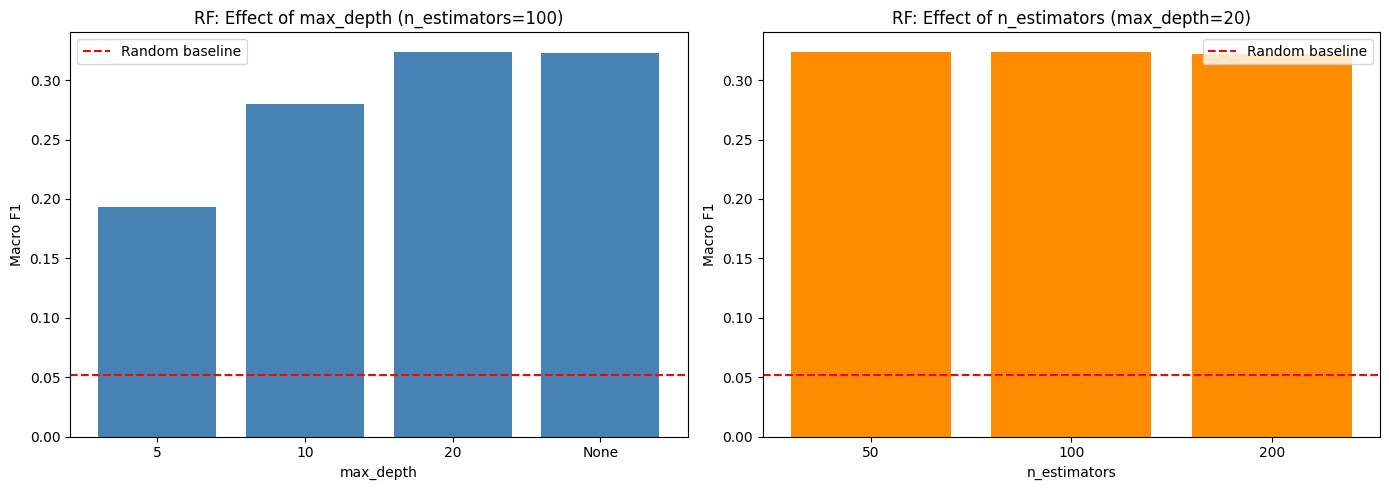


3(a) CLASSIFIER 2: K-NEAREST NEIGHBORS
Using subsample of 20000 segments for KNN training
  Training KNN: k=3, weights=uniform... Macro F1=0.3180, Balanced Acc=0.6200
  Training KNN: k=3, weights=distance... Macro F1=0.3180, Balanced Acc=0.6200
  Training KNN: k=5, weights=uniform... Macro F1=0.3024, Balanced Acc=0.6105
  Training KNN: k=5, weights=distance... Macro F1=0.3024, Balanced Acc=0.6105
  Training KNN: k=11, weights=uniform... Macro F1=0.2761, Balanced Acc=0.5986
  Training KNN: k=11, weights=distance... Macro F1=0.2761, Balanced Acc=0.5986
  Training KNN: k=21, weights=uniform... Macro F1=0.2519, Balanced Acc=0.5892
  Training KNN: k=21, weights=distance... Macro F1=0.2520, Balanced Acc=0.5892

Best KNN: k=3, weights=uniform
  Macro F1: 0.3180, Balanced Accuracy: 0.6200


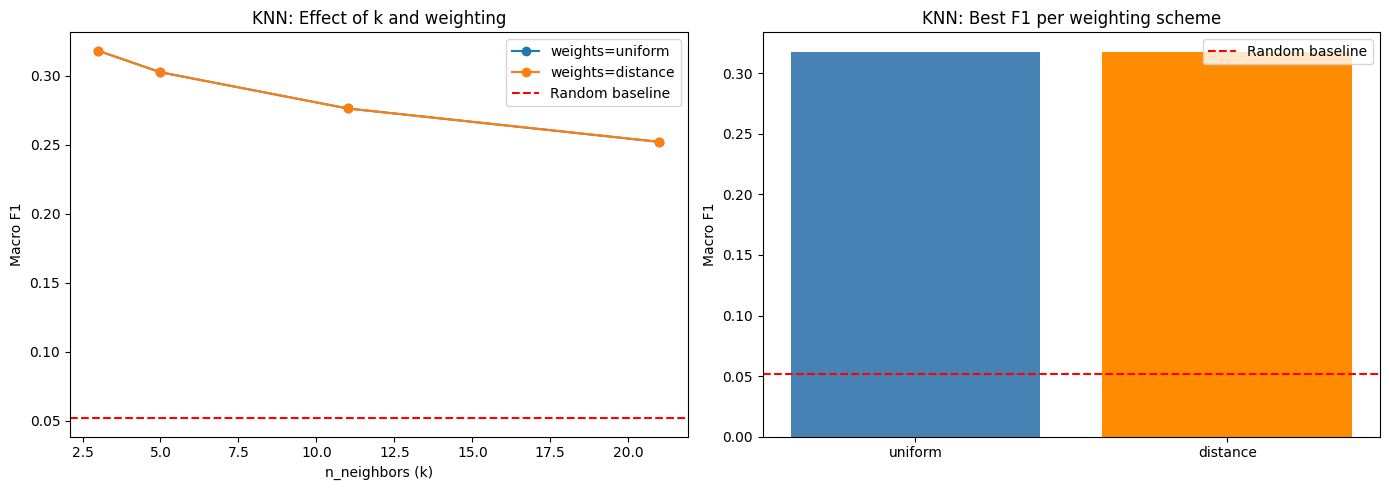

In [12]:
# ================================================================
# QUESTION 3: EXPERIMENTS (12 points)
# ================================================================
# 3(a) Two classifiers from different model classes
#      Classifier 1: Random Forest (ensemble of decision trees)
#      Classifier 2: K-Nearest Neighbors
#      Both wrapped in MultiOutputClassifier for multi-label support
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt

def evaluate(y_true, y_pred, class_names):
    """Compute per-class and macro F1 + balanced accuracy."""
    f1s, bals = [], []
    for c in range(y_true.shape[1]):
        f1s.append(f1_score(y_true[:, c], y_pred[:, c], zero_division=0))
        bals.append(balanced_accuracy_score(y_true[:, c], y_pred[:, c]))
    return np.array(f1s), np.mean(f1s), np.array(bals), np.mean(bals)


# ================================================================
# 3(a) CLASSIFIER 1: Random Forest
# ================================================================
# Hyperparameters to tune:
#   - n_estimators: number of trees (more = better but slower)
#   - max_depth: how deep each tree grows (controls overfitting)
# ================================================================

print("=" * 60)
print("3(a) CLASSIFIER 1: RANDOM FOREST")
print("=" * 60)

# --- Hyperparameter search ---
n_estimators_list = [50, 100, 200]
max_depth_list = [5, 10, 20, None]

rf_results = []

for n_est in n_estimators_list:
    for depth in max_depth_list:
        print(f"  Training RF: n_estimators={n_est}, max_depth={depth}...", end=" ")
        
        clf = MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=n_est, max_depth=depth,
                random_state=42, n_jobs=-1
            )
        )
        clf.fit(X_train_scaled, Y_train)
        Y_pred = clf.predict(X_val_scaled)
        
        _, macro_f1, _, macro_bal = evaluate(Y_val, Y_pred, class_names)
        rf_results.append({
            'n_estimators': n_est, 'max_depth': depth,
            'macro_f1': macro_f1, 'macro_bal': macro_bal
        })
        print(f"Macro F1={macro_f1:.4f}, Balanced Acc={macro_bal:.4f}")

# Find best RF
best_rf = max(rf_results, key=lambda x: x['macro_f1'])
print(f"\nBest RF: n_estimators={best_rf['n_estimators']}, max_depth={best_rf['max_depth']}")
print(f"  Macro F1: {best_rf['macro_f1']:.4f}, Balanced Accuracy: {best_rf['macro_bal']:.4f}")

# --- Visualize RF hyperparameter effect ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect of max_depth (fixing best n_estimators)
best_n = best_rf['n_estimators']
depths_plot = [r for r in rf_results if r['n_estimators'] == best_n]
depth_labels = [str(r['max_depth']) for r in depths_plot]
depth_f1s = [r['macro_f1'] for r in depths_plot]

axes[0].bar(depth_labels, depth_f1s, color='steelblue')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Macro F1')
axes[0].set_title(f'RF: Effect of max_depth (n_estimators={best_n})')
axes[0].axhline(y=np.mean(rand_f1), color='red', linestyle='--', label='Random baseline')
axes[0].legend()

# Plot 2: Effect of n_estimators (fixing best max_depth)
best_d = best_rf['max_depth']
nest_plot = [r for r in rf_results if r['max_depth'] == best_d]
nest_labels = [str(r['n_estimators']) for r in nest_plot]
nest_f1s = [r['macro_f1'] for r in nest_plot]

axes[1].bar(nest_labels, nest_f1s, color='darkorange')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Macro F1')
axes[1].set_title(f'RF: Effect of n_estimators (max_depth={best_d})')
axes[1].axhline(y=np.mean(rand_f1), color='red', linestyle='--', label='Random baseline')
axes[1].legend()

plt.tight_layout()
plt.savefig('rf_hyperparameters.png', dpi=150, bbox_inches='tight')
plt.show()


# ================================================================
# 3(a) CLASSIFIER 2: K-Nearest Neighbors
# ================================================================
# Hyperparameters to tune:
#   - n_neighbors: how many nearest points to consider
#   - weights: uniform (all neighbors equal) vs distance (closer = more weight)
#
# Note: Using a subsample for KNN because full dataset is slow
# ================================================================

print("\n" + "=" * 60)
print("3(a) CLASSIFIER 2: K-NEAREST NEIGHBORS")
print("=" * 60)

# Subsample training data for KNN (too slow on 116k segments)
sample_size = 20000
np.random.seed(42)
knn_idx = np.random.choice(len(X_train_scaled), size=sample_size, replace=False)
X_train_knn = X_train_scaled[knn_idx]
Y_train_knn = Y_train[knn_idx]
print(f"Using subsample of {sample_size} segments for KNN training")

n_neighbors_list = [3, 5, 11, 21]
weights_list = ['uniform', 'distance']

knn_results = []

for k in n_neighbors_list:
    for w in weights_list:
        print(f"  Training KNN: k={k}, weights={w}...", end=" ")
        
        clf = MultiOutputClassifier(
            KNeighborsClassifier(n_neighbors=k, weights=w, n_jobs=-1)
        )
        clf.fit(X_train_knn, Y_train_knn)
        Y_pred = clf.predict(X_val_scaled)
        
        _, macro_f1, _, macro_bal = evaluate(Y_val, Y_pred, class_names)
        knn_results.append({
            'n_neighbors': k, 'weights': w,
            'macro_f1': macro_f1, 'macro_bal': macro_bal
        })
        print(f"Macro F1={macro_f1:.4f}, Balanced Acc={macro_bal:.4f}")

# Find best KNN
best_knn = max(knn_results, key=lambda x: x['macro_f1'])
print(f"\nBest KNN: k={best_knn['n_neighbors']}, weights={best_knn['weights']}")
print(f"  Macro F1: {best_knn['macro_f1']:.4f}, Balanced Accuracy: {best_knn['macro_bal']:.4f}")

# --- Visualize KNN hyperparameter effect ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot: uniform vs distance for each k
for idx, w in enumerate(weights_list):
    subset = [r for r in knn_results if r['weights'] == w]
    ks = [r['n_neighbors'] for r in subset]
    f1s = [r['macro_f1'] for r in subset]
    axes[0].plot(ks, f1s, marker='o', label=f'weights={w}')

axes[0].set_xlabel('n_neighbors (k)')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('KNN: Effect of k and weighting')
axes[0].axhline(y=np.mean(rand_f1), color='red', linestyle='--', label='Random baseline')
axes[0].legend()

# Plot: bar chart comparing best of each weight
for idx, w in enumerate(weights_list):
    best_w = max([r for r in knn_results if r['weights'] == w], key=lambda x: x['macro_f1'])
    axes[1].bar(w, best_w['macro_f1'], color=['steelblue', 'darkorange'][idx])

axes[1].set_ylabel('Macro F1')
axes[1].set_title('KNN: Best F1 per weighting scheme')
axes[1].axhline(y=np.mean(rand_f1), color='red', linestyle='--', label='Random baseline')
axes[1].legend()

plt.tight_layout()
plt.savefig('knn_hyperparameters.png', dpi=150, bbox_inches='tight')
plt.show()




3(a) CLASSIFIER 1: RANDOM FOREST
  Training RF: n_estimators=100, max_depth=25... Macro F1=0.3200, Balanced Acc=0.6147

Best RF: n_estimators=100, max_depth=25
  Macro F1: 0.3200, Balanced Accuracy: 0.6147


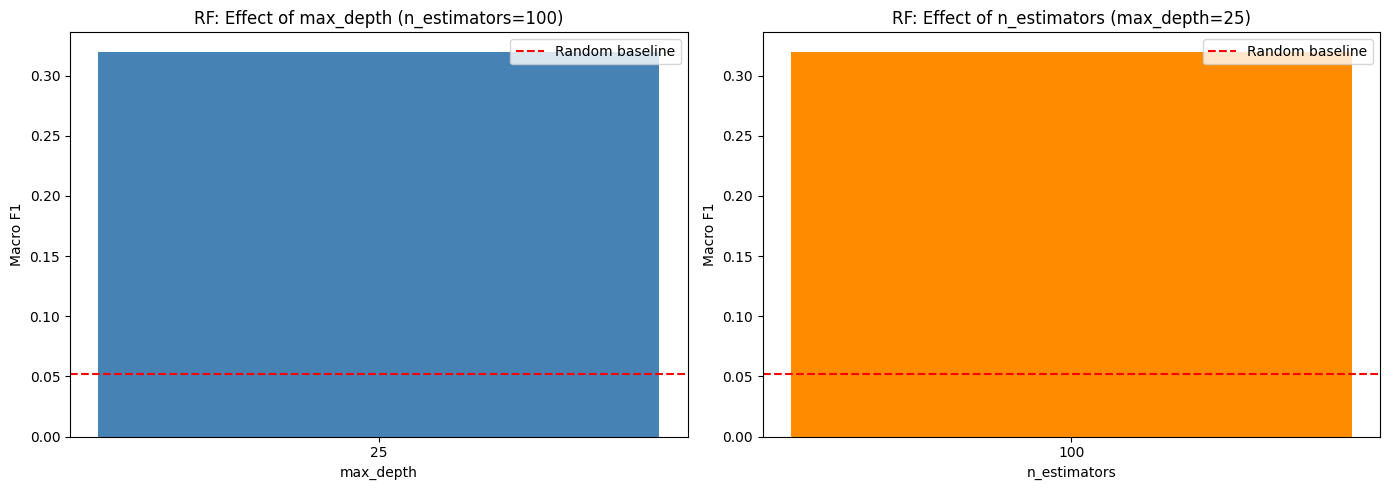

In [18]:
# ================================================================
# QUESTION 3: EXPERIMENTS (12 points)
# ================================================================
# 3(a) Two classifiers from different model classes
#      Classifier 1: Random Forest (ensemble of decision trees)
#      Classifier 2: K-Nearest Neighbors
#      Both wrapped in MultiOutputClassifier for multi-label support
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt

def evaluate(y_true, y_pred, class_names):
    """Compute per-class and macro F1 + balanced accuracy."""
    f1s, bals = [], []
    for c in range(y_true.shape[1]):
        f1s.append(f1_score(y_true[:, c], y_pred[:, c], zero_division=0))
        bals.append(balanced_accuracy_score(y_true[:, c], y_pred[:, c]))
    return np.array(f1s), np.mean(f1s), np.array(bals), np.mean(bals)


# ================================================================
# 3(a) CLASSIFIER 1: Random Forest
# ================================================================
# Hyperparameters to tune:
#   - n_estimators: number of trees (more = better but slower)
#   - max_depth: how deep each tree grows (controls overfitting)
# ================================================================

print("=" * 60)
print("3(a) CLASSIFIER 1: RANDOM FOREST")
print("=" * 60)

# --- Hyperparameter search ---
n_estimators_list = [100]
max_depth_list = [25]

rf_results = []

for n_est in n_estimators_list:
    for depth in max_depth_list:
        print(f"  Training RF: n_estimators={n_est}, max_depth={depth}...", end=" ")
        
        clf = MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=n_est, max_depth=depth,
                random_state=42, n_jobs=-1
            )
        )
        clf.fit(X_train_scaled, Y_train)
        Y_pred = clf.predict(X_val_scaled)
        
        _, macro_f1, _, macro_bal = evaluate(Y_val, Y_pred, class_names)
        rf_results.append({
            'n_estimators': n_est, 'max_depth': depth,
            'macro_f1': macro_f1, 'macro_bal': macro_bal
        })
        print(f"Macro F1={macro_f1:.4f}, Balanced Acc={macro_bal:.4f}")

# Find best RF
best_rf = max(rf_results, key=lambda x: x['macro_f1'])
print(f"\nBest RF: n_estimators={best_rf['n_estimators']}, max_depth={best_rf['max_depth']}")
print(f"  Macro F1: {best_rf['macro_f1']:.4f}, Balanced Accuracy: {best_rf['macro_bal']:.4f}")

# --- Visualize RF hyperparameter effect ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect of max_depth (fixing best n_estimators)
best_n = best_rf['n_estimators']
depths_plot = [r for r in rf_results if r['n_estimators'] == best_n]
depth_labels = [str(r['max_depth']) for r in depths_plot]
depth_f1s = [r['macro_f1'] for r in depths_plot]

axes[0].bar(depth_labels, depth_f1s, color='steelblue')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Macro F1')
axes[0].set_title(f'RF: Effect of max_depth (n_estimators={best_n})')
axes[0].axhline(y=np.mean(rand_f1), color='red', linestyle='--', label='Random baseline')
axes[0].legend()

# Plot 2: Effect of n_estimators (fixing best max_depth)
best_d = best_rf['max_depth']
nest_plot = [r for r in rf_results if r['max_depth'] == best_d]
nest_labels = [str(r['n_estimators']) for r in nest_plot]
nest_f1s = [r['macro_f1'] for r in nest_plot]

axes[1].bar(nest_labels, nest_f1s, color='darkorange')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Macro F1')
axes[1].set_title(f'RF: Effect of n_estimators (max_depth={best_d})')
axes[1].axhline(y=np.mean(rand_f1), color='red', linestyle='--', label='Random baseline')
axes[1].legend()

plt.tight_layout()
plt.savefig('rf_hyperparameters.png', dpi=150, bbox_inches='tight')
plt.show()







In [13]:
# ================================================================
# 3(b) FINAL COMPARISON: Best classifiers vs baseline
# ================================================================

print("\n" + "=" * 60)
print("3(b) FINAL COMPARISON")
print("=" * 60)

# Retrain best RF on full training data and evaluate on TEST set
print("\nRetraining best RF on full training data...")
best_rf_clf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=best_rf['n_estimators'],
        max_depth=best_rf['max_depth'],
        random_state=42, n_jobs=-1
    )
)
best_rf_clf.fit(X_train_scaled, Y_train)
Y_pred_rf_test = best_rf_clf.predict(X_test_scaled)
rf_f1s, rf_macro_f1, rf_bals, rf_macro_bal = evaluate(Y_test, Y_pred_rf_test, class_names)

# Retrain best KNN and evaluate on TEST set
print("Retraining best KNN...")
best_knn_clf = MultiOutputClassifier(
    KNeighborsClassifier(
        n_neighbors=best_knn['n_neighbors'],
        weights=best_knn['weights'], n_jobs=-1
    )
)
best_knn_clf.fit(X_train_knn, Y_train_knn)
Y_pred_knn_test = best_knn_clf.predict(X_test_scaled)
knn_f1s, knn_macro_f1, knn_bals, knn_macro_bal = evaluate(Y_test, Y_pred_knn_test, class_names)

# Random baseline on test set
np.random.seed(42)
Y_pred_rand_test = np.zeros_like(Y_test)
for c in range(len(class_names)):
    Y_pred_rand_test[:, c] = np.random.binomial(1, train_freqs[c], size=len(Y_test))
rand_f1_test, rand_macro_f1_test, rand_bal_test, rand_macro_bal_test = evaluate(Y_test, Y_pred_rand_test, class_names)

print(f"\n{'Method':<25} {'Macro F1':>10} {'Macro BalAcc':>14}")
print("-" * 50)
print(f"{'Random baseline':<25} {rand_macro_f1_test:>10.4f} {rand_macro_bal_test:>14.4f}")
print(f"{'KNN (best)':<25} {knn_macro_f1:>10.4f} {knn_macro_bal:>14.4f}")
print(f"{'Random Forest (best)':<25} {rf_macro_f1:>10.4f} {rf_macro_bal:>14.4f}")

# Per-class comparison
print(f"\nPer-class F1 on test set:")
print(f"  {'Class':<35} {'Baseline':>8} {'KNN':>8} {'RF':>8}")
print(f"  {'-'*62}")
for i, name in enumerate(class_names):
    print(f"  {name:<35} {rand_f1_test[i]:>8.4f} {knn_f1s[i]:>8.4f} {rf_f1s[i]:>8.4f}")


3(b) FINAL COMPARISON

Retraining best RF on full training data...
Retraining best KNN...

Method                      Macro F1   Macro BalAcc
--------------------------------------------------
Random baseline               0.0525         0.5001
KNN (best)                    0.3262         0.6203
Random Forest (best)          0.3316         0.6180

Per-class F1 on test set:
  Class                               Baseline      KNN       RF
  --------------------------------------------------------------
  bell_ringing                          0.0032   0.2730   0.3161
  coffee_machine                        0.0325   0.4017   0.5626
  cutlery_dishes                        0.0575   0.3069   0.3559
  door_open_close                       0.0434   0.1570   0.0344
  footsteps                             0.1174   0.3204   0.1463
  keyboard_typing                       0.1006   0.4550   0.5290
  keychain                              0.0340   0.3907   0.4407
  light_switch                       

Top 10 test files by number of classes:
  002690.wav: 5 classes — ['door_open_close', 'footsteps', 'keyboard_typing', 'light_switch', 'microwave']
  004874.wav: 5 classes — ['door_open_close', 'footsteps', 'keychain', 'light_switch', 'window_open_close']
  004880.wav: 5 classes — ['bell_ringing', 'door_open_close', 'footsteps', 'keychain', 'toilet_flushing']
  000118.wav: 4 classes — ['door_open_close', 'footsteps', 'running_water', 'vacuum_cleaner']
  000122.wav: 4 classes — ['cutlery_dishes', 'footsteps', 'microwave', 'running_water']
  000472.wav: 4 classes — ['cutlery_dishes', 'door_open_close', 'footsteps', 'running_water']
  000743.wav: 4 classes — ['door_open_close', 'footsteps', 'keychain', 'phone_ringing']
  000899.wav: 4 classes — ['door_open_close', 'footsteps', 'running_water', 'toilet_flushing']
  001120.wav: 4 classes — ['door_open_close', 'footsteps', 'light_switch', 'wardrobe_drawer_open_close']
  001381.wav: 4 classes — ['door_open_close', 'footsteps', 'keyboard_typing

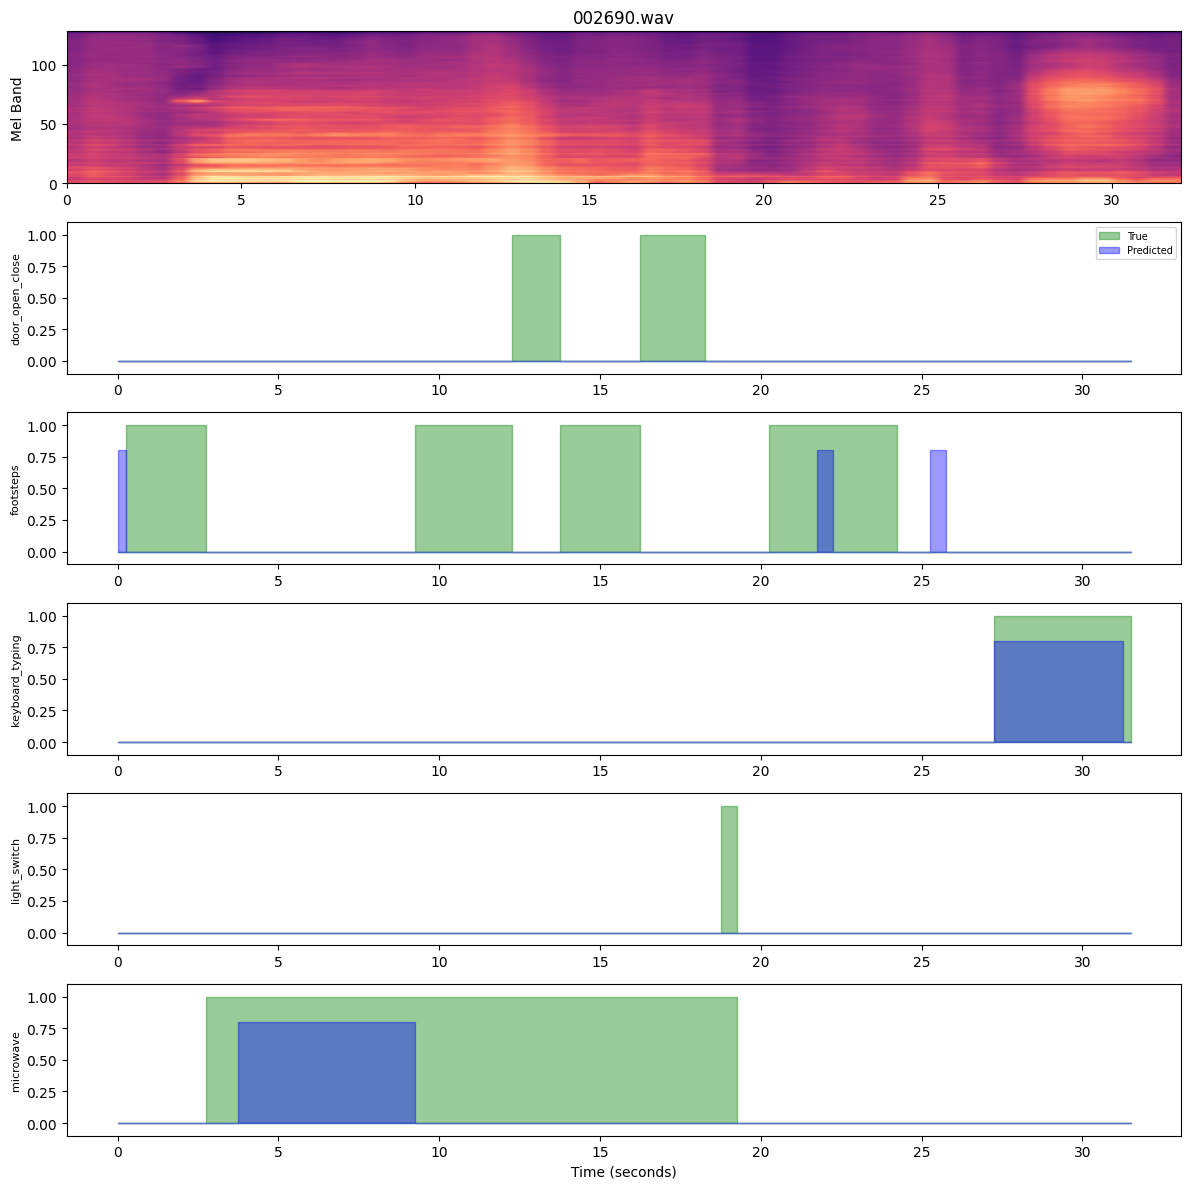


002690.wav:
  door_open_close                     true=7 pred=0 F1=0.0000
  footsteps                           true=24 pred=3 F1=0.0741
  keyboard_typing                     true=9 pred=8 F1=0.9412
  light_switch                        true=1 pred=0 F1=0.0000
  microwave                           true=33 pred=11 F1=0.5000


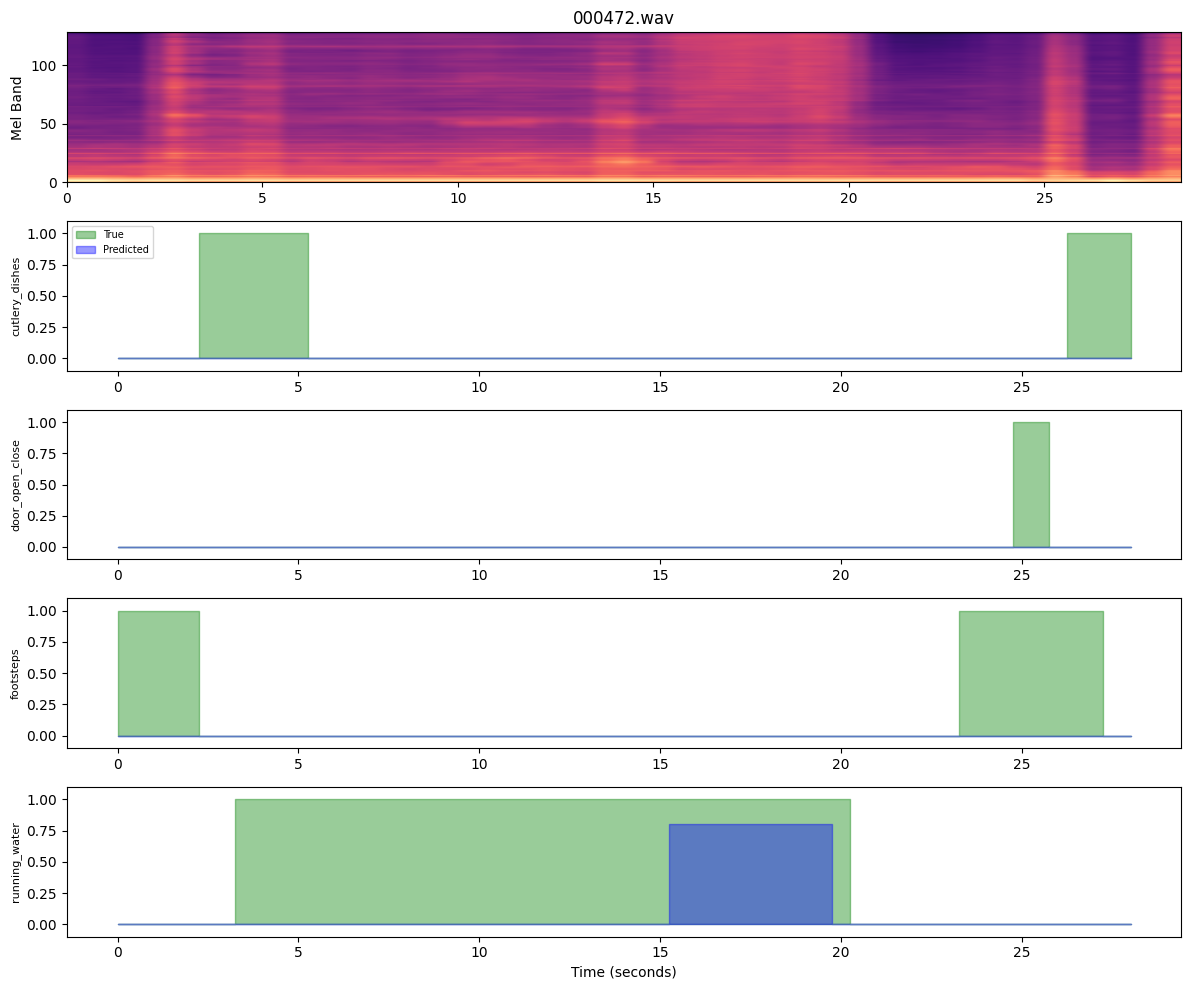


000472.wav:
  cutlery_dishes                      true=10 pred=0 F1=0.0000
  door_open_close                     true=2 pred=0 F1=0.0000
  footsteps                           true=13 pred=0 F1=0.0000
  running_water                       true=34 pred=9 F1=0.4186


In [16]:
# ================================================================
# QUESTION 4: CASE STUDY AND REFLECTION
# ================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# ================================================================
# 4(a) Pick 2 test files, show predictions vs true labels
# ================================================================

# Find test files with multiple classes
test_unique_files = np.unique(filenames_test)

file_info = []
for fname in test_unique_files:
    mask = filenames_test == fname
    y_true = Y_test[mask]
    n_classes = (y_true.sum(axis=0) > 0).sum()
    classes = [class_names[i] for i in range(15) if y_true[:, i].sum() > 0]
    file_info.append((fname, n_classes, classes))

file_info.sort(key=lambda x: x[1], reverse=True)

print("Top 10 test files by number of classes:")
for fname, nc, cls in file_info[:10]:
    print(f"  {fname}: {nc} classes — {cls}")

# Select two files
case_file_1 = file_info[0][0]
case_file_2 = file_info[5][0]


# --- Visualize one file ---
def plot_case_study(filename):
    mask = filenames_test == filename
    y_true = Y_test[mask]
    y_pred = best_rf_clf.predict(X_test_scaled[mask])
    
    # Load spectrogram
    npz_path = dataset_path / 'audio_features' / filename.replace('.wav', '.npz')
    melspect = np.load(npz_path, allow_pickle=True)['melspect_mean']
    
    # Find active classes (true or predicted)
    active = [c for c in range(15) if y_true[:, c].sum() > 0 or y_pred[:, c].sum() > 0]
    time_axis = np.arange(y_true.shape[0]) * 0.5
    
    # Plot
    fig, axes = plt.subplots(1 + len(active), 1, figsize=(12, 2 * (1 + len(active))))
    
    axes[0].imshow(melspect.T, aspect='auto', origin='lower', cmap='magma',
                   extent=[0, time_axis[-1]+0.5, 0, 128])
    axes[0].set_ylabel('Mel Band')
    axes[0].set_title(f'{filename}')
    
    for idx, c in enumerate(active):
        ax = axes[1 + idx]
        ax.fill_between(time_axis, 0, y_true[:, c], alpha=0.4, color='green', step='mid', label='True')
        ax.fill_between(time_axis, 0, y_pred[:, c] * 0.8, alpha=0.4, color='blue', step='mid', label='Predicted')
        f1 = f1_score(y_true[:, c], y_pred[:, c], zero_division=0)
        ax.set_ylabel(class_names[c], fontsize=8)
        ax.set_ylim(-0.1, 1.1)
        if idx == 0:
            ax.legend(fontsize=7)
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.savefig(f'case_study_{filename.replace(".wav","")}.png', dpi=150)
    plt.show()
    
    # Print summary
    print(f"\n{filename}:")
    for c in active:
        f1 = f1_score(y_true[:, c], y_pred[:, c], zero_division=0)
        print(f"  {class_names[c]:35s} true={int(y_true[:,c].sum())} pred={int(y_pred[:,c].sum())} F1={f1:.4f}")


plot_case_study(case_file_1)
plot_case_study(case_file_2)




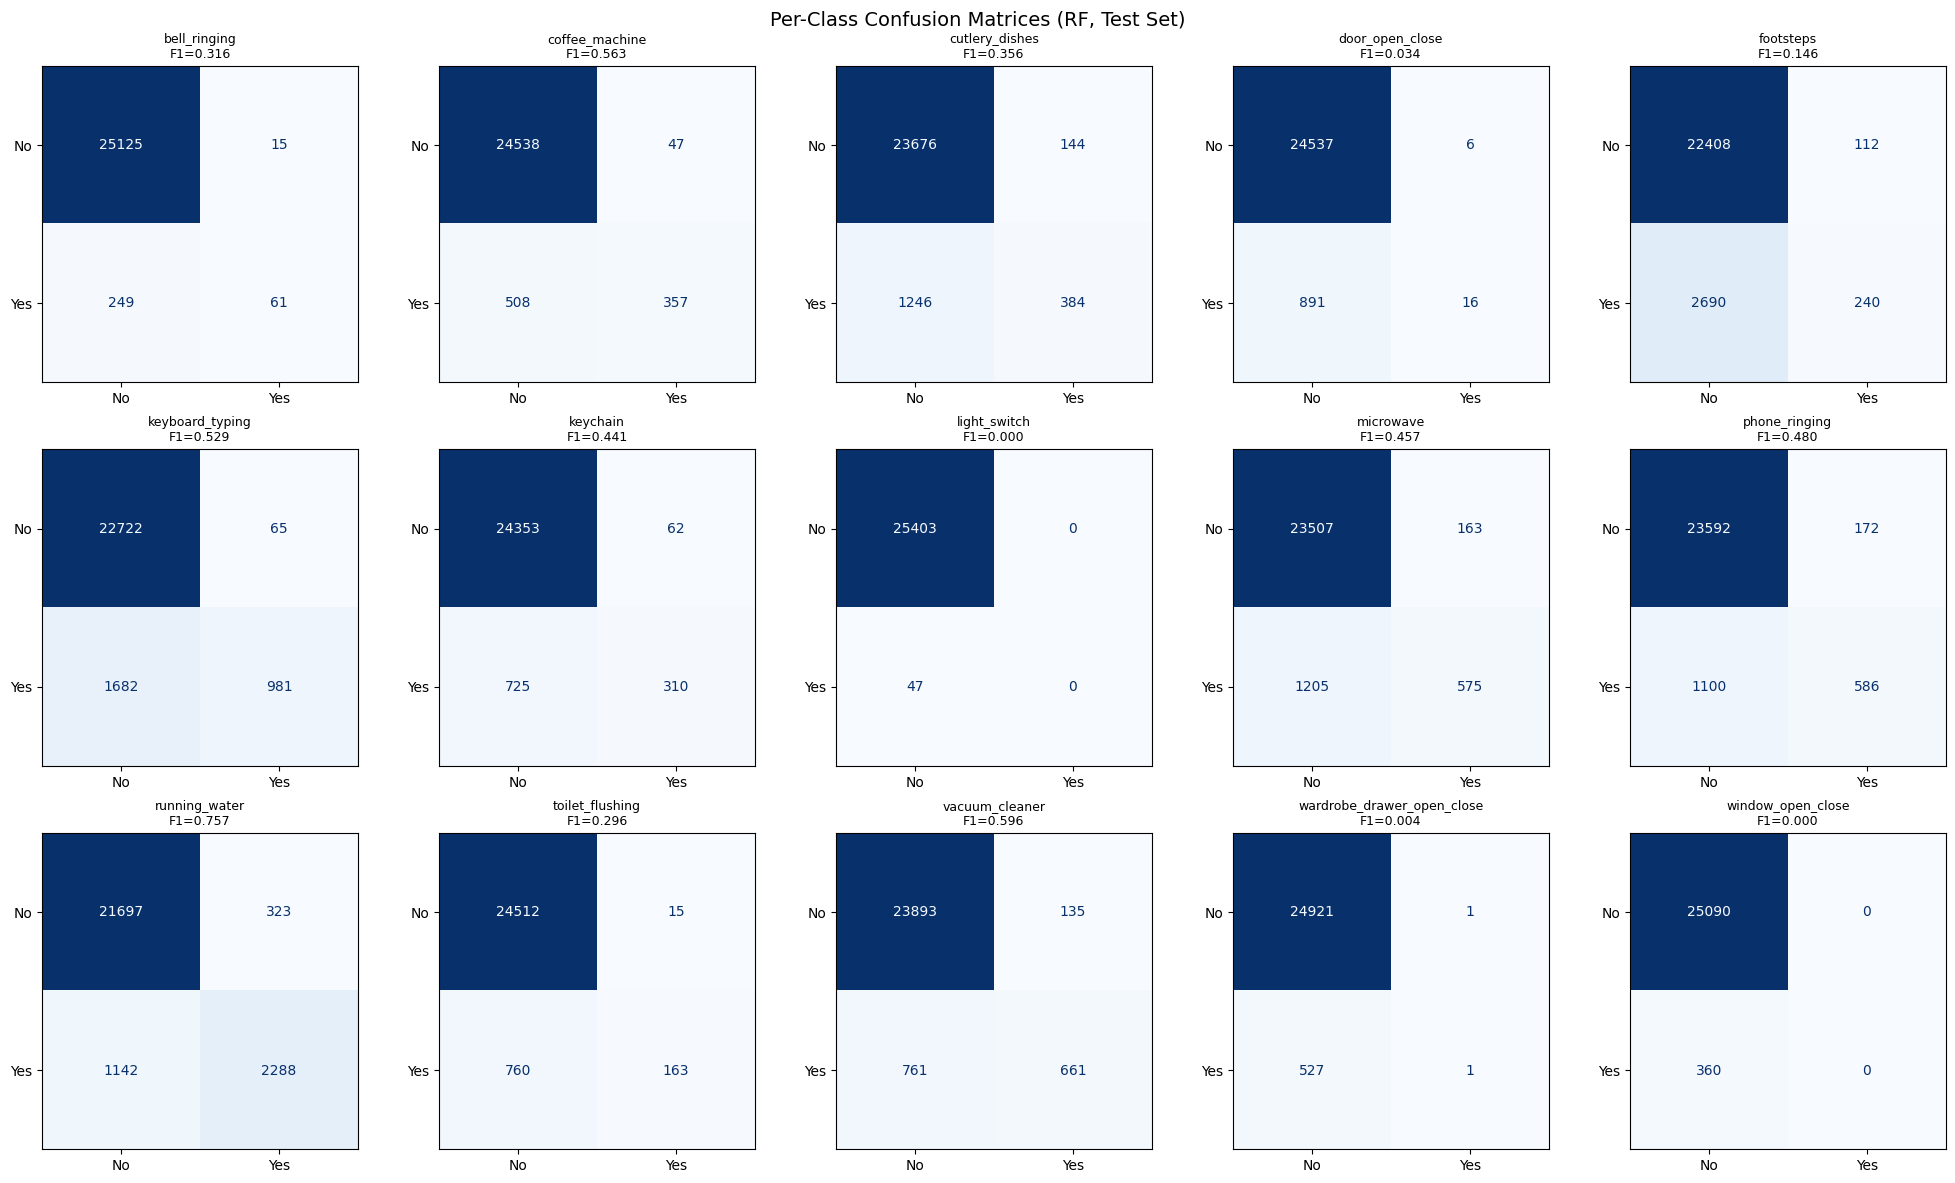


Classes ranked by F1:
  running_water                       F1=0.7575  support=3430
  vacuum_cleaner                      F1=0.5960  support=1422
  coffee_machine                      F1=0.5626  support=865
  keyboard_typing                     F1=0.5290  support=2663
  phone_ringing                       F1=0.4795  support=1686
  microwave                           F1=0.4567  support=1780
  keychain                            F1=0.4407  support=1035
  cutlery_dishes                      F1=0.3559  support=1630
  bell_ringing                        F1=0.3161  support=310
  toilet_flushing                     F1=0.2961  support=923
  footsteps                           F1=0.1463  support=2930
  door_open_close                     F1=0.0344  support=907
  wardrobe_drawer_open_close          F1=0.0038  support=528
  light_switch                        F1=0.0000  support=47
  window_open_close                   F1=0.0000  support=360


In [17]:
# ================================================================
# 4(b) Per-class confusion matrices + failure analysis
# ================================================================

Y_pred_rf_test = best_rf_clf.predict(X_test_scaled)

# Confusion matrices
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Per-Class Confusion Matrices (RF, Test Set)', fontsize=14)

for i, name in enumerate(class_names):
    ax = axes[i // 5, i % 5]
    cm = confusion_matrix(Y_test[:, i], Y_pred_rf_test[:, i])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, cmap='Blues', colorbar=False)
    f1 = f1_score(Y_test[:, i], Y_pred_rf_test[:, i], zero_division=0)
    ax.set_title(f'{name}\nF1={f1:.3f}', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Class ranking
print("\nClasses ranked by F1:")
per_class_f1 = [f1_score(Y_test[:, i], Y_pred_rf_test[:, i], zero_division=0) for i in range(15)]
for c in sorted(range(15), key=lambda c: per_class_f1[c], reverse=True):
    print(f"  {class_names[c]:35s} F1={per_class_f1[c]:.4f}  support={int(Y_test[:,c].sum())}")